<a href="https://colab.research.google.com/github/Pavan0-18/Task_1/blob/main/deepfakedetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install kaggle

In [7]:
from google.colab import files
files.upload()  # Upload the kaggle.json file

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"pasupuletipavan","key":"62239410006ea58161d750b82e7b9c0d"}'}

In [8]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [11]:
!kaggle datasets download -d ciplab/real-and-fake-face-detection

Dataset URL: https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection
License(s): CC-BY-NC-SA-4.0
 99% 429M/431M [00:04<00:00, 33.6MB/s]
100% 431M/431M [00:04<00:00, 109MB/s] 


In [12]:
!unzip real-and-fake-face-detection.zip -d dataset

Archive:  real-and-fake-face-detection.zip
  inflating: dataset/real_and_fake_face/training_fake/easy_100_1111.jpg  
  inflating: dataset/real_and_fake_face/training_fake/easy_101_0010.jpg  
  inflating: dataset/real_and_fake_face/training_fake/easy_102_0101.jpg  
  inflating: dataset/real_and_fake_face/training_fake/easy_103_1111.jpg  
  inflating: dataset/real_and_fake_face/training_fake/easy_104_1000.jpg  
  inflating: dataset/real_and_fake_face/training_fake/easy_105_1100.jpg  
  inflating: dataset/real_and_fake_face/training_fake/easy_106_0011.jpg  
  inflating: dataset/real_and_fake_face/training_fake/easy_107_1011.jpg  
  inflating: dataset/real_and_fake_face/training_fake/easy_108_1111.jpg  
  inflating: dataset/real_and_fake_face/training_fake/easy_109_1111.jpg  
  inflating: dataset/real_and_fake_face/training_fake/easy_10_0001.jpg  
  inflating: dataset/real_and_fake_face/training_fake/easy_110_0001.jpg  
  inflating: dataset/real_and_fake_face/training_fake/easy_111_1101.jp

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def load_and_preprocess_data(data_dir, class_names, img_size=(224, 224)):
    images = []
    labels = []

    for class_name in class_names:
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: Directory {class_dir} does not exist.")
            continue

        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, img_size)  # Resize image
                img = img / 255.0  # Normalize pixel values to [0, 1]
                images.append(img)
                labels.append(class_names.index(class_name))  # Assign label based on class index

    return np.array(images), np.array(labels)

# Define dataset paths
train_dir = "/content/dataset/real_and_fake_face"  # Training dataset folder

# Define class names
train_classes = ["training_real", "training_fake"]

# Load datasets
X, y = load_and_preprocess_data(train_dir, train_classes)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}, Labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Labels shape: {y_test.shape}")

Training data shape: (1632, 224, 224, 3), Labels shape: (1632,)
Testing data shape: (409, 224, 224, 3), Labels shape: (409,)


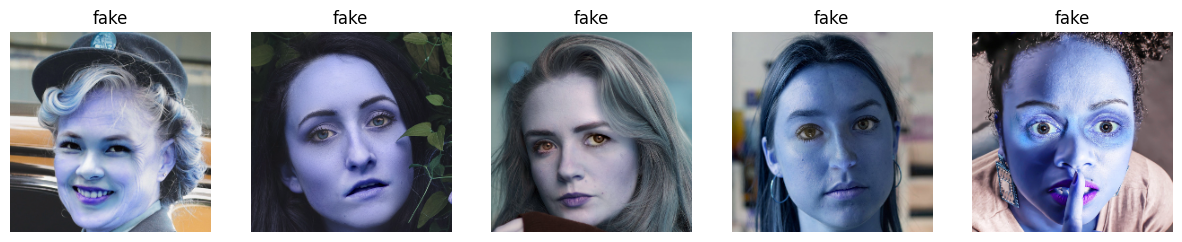

In [3]:
# Function to display sample images
def plot_sample_images(images, labels, class_names, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

# Plot sample images from the training dataset
plot_sample_images(X_train, y_train, ["real", "fake"])

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load pre-trained EfficientNetB0 model
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze the base model
base_model.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation="sigmoid")(x)  # Binary classification (real or fake)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 196s 4s/step - accuracy: 0.5124 - loss: 0.7138 - val_accuracy: 0.5330 - val_loss: 0.6930
Epoch 2/10
